**Importing the Dependencies**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

**Time-Series Preparation**

Convert Date to datetime index

In [5]:
data = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date"])
data = data.sort_values("Date")
data.set_index("Date", inplace=True)

 Ensure continuity of daily observations

In [6]:
print(data.shape)
print(data.head())


(720, 5)
            Children apprehended and placed in CBP custody*  \
Date                                                          
2023-01-12                                             33.0   
2023-01-22                                             32.0   
2023-01-23                                             32.0   
2023-01-24                                             47.0   
2023-01-25                                             20.0   

            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-01-12                     53.0                                     34.0   
2023-01-22                     49.0                                     39.0   
2023-01-23                     50.0                                     39.0   
2023-01-24                     42.0                                     47.0   
2023-01-25                     22.0                                  

HHandle missing days via interpolation or masking

In [8]:
for col in [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]:
    data[col] = pd.to_numeric(data[col], errors="coerce")


In [9]:
data = data.interpolate(method="time")

 Decompose series into trend, seasonality, and residuals

In [10]:
if len(data["Children in HHS Care"].dropna()) >= 14:
    decompos = seasonal_decompose(
        data["Children in HHS Care"],
        model="additive",
        period=7,
        extrapolate_trend="freq"
    )
    decompos.plot()
    plt.show()
else:
    print("Not enough data for seasonal decomposition (need at least 14 observations).")


Not enough data for seasonal decomposition (need at least 14 observations).


**Feature Engineering**

In [11]:
df = data.copy()

In [12]:
df["lag1"] = df["Children in HHS Care"].shift(1)
df["lag7"] = df["Children in HHS Care"].shift(7)
df["lag14"] = df["Children in HHS Care"].shift(14)

In [13]:
df["roll_mean7"] = df["Children in HHS Care"].rolling(7).mean()
df["roll_var7"] = df["Children in HHS Care"].rolling(7).var()

In [14]:
df["net_pressure"] = df["Children transferred out of CBP custody"] - df["Children discharged from HHS Care"]

In [15]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month

In [16]:
df=df.dropna()

**Train-Test Split (time-based)**

In [25]:
X = data.drop("Children discharged from HHS Care", axis=1)   # replace target_column with your actual target
y = data["Children discharged from HHS Care"]


In [26]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train.drop(columns=["Children in HHS Care"])
y_train = train["Children in HHS Care"]
X_test = test.drop(columns=["Children in HHS Care"])
y_test = test["Children in HHS Care"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Machine Learning Models**

In [27]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [31]:
print(X_train.isnull().sum())   # if X_train is a DataFrame
print(np.isnan(X_train).any())

Children apprehended and placed in CBP custody*      0
Children in CBP custody                              0
Children transferred out of CBP custody              0
Children in HHS Care                               860
dtype: int64
Children apprehended and placed in CBP custody*    False
Children in CBP custody                            False
Children transferred out of CBP custody            False
Children in HHS Care                                True
dtype: bool


In [33]:
X = X.dropna()
y = y.loc[X.index]  # keep target aligned


In [30]:
X.fillna(0, inplace=True)


In [38]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


In [39]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")


Random Forest -> MAE: 62.18, RMSE: 83.66, MAPE: 77.65%
Gradient Boosting -> MAE: 59.12, RMSE: 79.73, MAPE: 65.12%


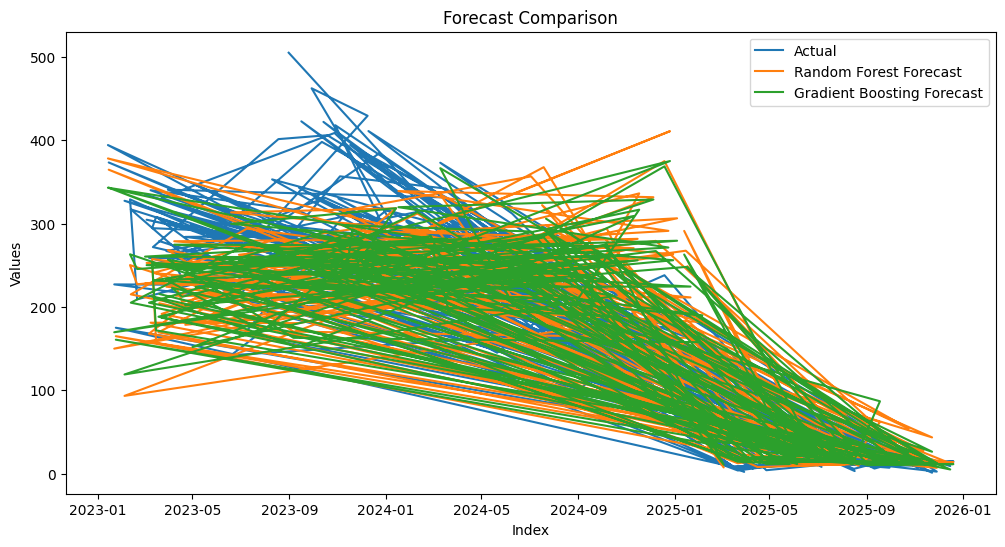

In [53]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_rf, label="Random Forest Forecast")
plt.plot(y_test.index, y_pred_gb, label="Gradient Boosting Forecast")
plt.legend()
plt.title("Forecast Comparison")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()